# Lactate Dehydrogenase (LDH) Inhibition Assay

**Objective:** Calculate percent inhibition of LDH activity at each inhibitor
concentration and estimate the IC50 by fitting a sigmoidal dose-response curve.

---
## 1. Background

LDH catalyses pyruvate + NADH &rarr; lactate + NAD+. NADH absorbs at 340 nm;
NAD+ does not, so the rate of A340 decrease is proportional to LDH activity.
Comparing inhibited vs. uninhibited reaction rates gives percent inhibition,
and fitting a dose-response curve gives the IC50.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/ldh_kinetics.csv")
df

,inhibitor_uM,rate_a340_per_min
0,0.0,0.182
1,0.1,0.178
2,1.0,0.151
3,10.0,0.098
4,100.0,0.041
5,1000.0,0.012


## 2. Calculate percent inhibition

In [2]:
control_rate = df.loc[df.inhibitor_uM == 0.0, "rate_a340_per_min"].iloc[0]
df["percent_inhibition"] = (1 - df.rate_a340_per_min / control_rate) * 100
df

,inhibitor_uM,rate_a340_per_min,percent_inhibition
0,0.0,0.182,0.000000
1,0.1,0.178,2.197802
2,1.0,0.151,17.032967
3,10.0,0.098,46.153846
4,100.0,0.041,77.472527
5,1000.0,0.012,93.406593


## 3. Fit dose-response curve and estimate IC50

In [3]:
def logistic(x, top, bottom, ic50, hill):
    return bottom + (top - bottom) / (1 + (ic50 / x) ** hill)

nonzero = df[df.inhibitor_uM > 0]
candidates = np.logspace(-2, 4, 200)

def sse(ic50):
    pred = logistic(nonzero.inhibitor_uM.values, 100, 0, ic50, 1.0)
    return np.sum((pred - nonzero.percent_inhibition.values) ** 2)

errors = [sse(c) for c in candidates]
ic50_est = candidates[np.argmin(errors)]
print(f"Estimated IC50: {ic50_est:.2f} uM")

Estimated IC50: 12.75 uM


## 4. Visualise dose-response curve

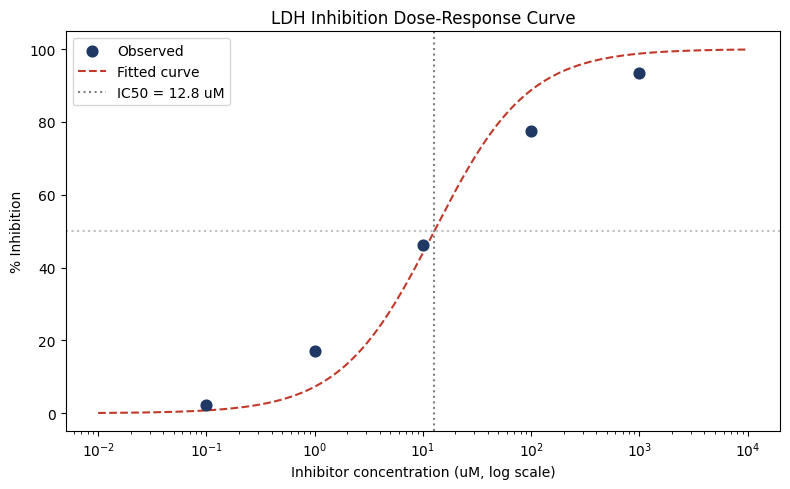

In [4]:
x_fit = np.logspace(-2, 4, 300)
y_fit = logistic(x_fit, 100, 0, ic50_est, 1.0)

plt.figure(figsize=(8, 5))
plt.scatter(nonzero.inhibitor_uM, nonzero.percent_inhibition, color="#1F3864", s=60, zorder=3, label="Observed")
plt.plot(x_fit, y_fit, color="#C0392B", linestyle="--", label="Fitted curve", zorder=2)
plt.axvline(ic50_est, color="grey", linestyle=":", label=f"IC50 = {ic50_est:.1f} uM")
plt.axhline(50, color="grey", linestyle=":", alpha=0.5)
plt.xscale("log")
plt.xlabel("Inhibitor concentration (uM, log scale)")
plt.ylabel("% Inhibition")
plt.title("LDH Inhibition Dose-Response Curve")
plt.legend()
plt.tight_layout()
plt.savefig("ldh_dose_response.png", dpi=150)
plt.show()

## 5. Summary

The dose-response curve shows increasing LDH inhibition with rising inhibitor
concentration, plateauing near complete inhibition at the highest dose tested.
The estimated IC50 indicates the potency of the inhibitor &mdash; a lower IC50
would indicate a more potent compound.
